In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
# Reading data from the pipeline
data = pd.read_csv('D:\DataAnalyst\web scraping projects\Aqar\Data\Aqarmap_Cleaned_Ready_pipeline.csv')
data.head()

,URL,Title,Location,Price,District,Area,Bedrooms,Bathrooms,Budget_Category,Total_Rooms,Price_per_m²
0,https://aqarmap.com.eg/en/listing/6879964-for-...,Apartment for rent in lake view residence in L...,New Cairo - 5th Settlemet,70000.0,Lake View Residence - El Hazek,142,2,2,Luxury,4,492.96
1,https://aqarmap.com.eg/en/listing/6878780-for-...,Apartment For rent in Street 21 in Street 21 ....,New Cairo - 5th Settlemet,30000.0,Street 21,300,4,3,Luxury,7,100.00
2,https://aqarmap.com.eg/en/listing/6878233-for-...,Apartment View Lake 3BR for rent in lake view ...,New Cairo - 5th Settlemet,80000.0,Lake View Residence - El Hazek,210,3,2,Luxury,5,380.95
3,https://aqarmap.com.eg/en/listing/6877958-for-...,سكني For rent in Abd El Rahman Ouda St. in Abd...,New Cairo - 5th Settlemet,50000.0,Abd El Rahman Ouda St.,220,3,2,Luxury,5,227.27
4,https://aqarmap.com.eg/en/listing/6753607-for-...,دوبليكس للإيجار باللوتس الشماليه على90 وخطوات ...,New Cairo - 5th Settlemet,25000.0,The Second Area - Lotus North,256,4,4,Luxury,8,97.66


<Axes: xlabel='Price', ylabel='Count'>

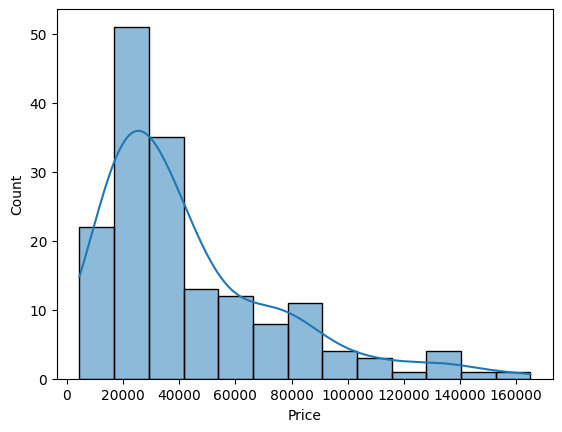

In [12]:
# The distribution of the prices
sns.histplot(data,x='Price',kde=True)

<Axes: xlabel='Price', ylabel='Area'>

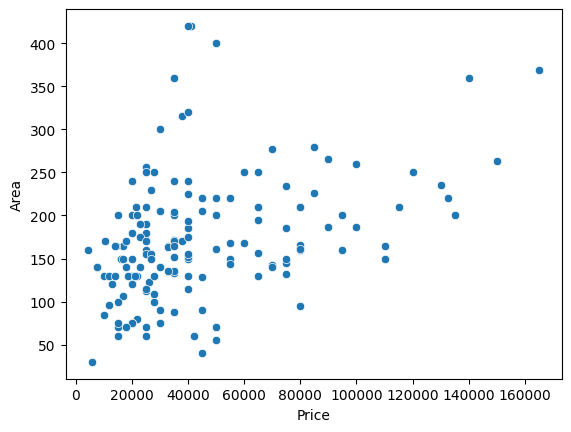

In [13]:
# What is the relationship between Area and the price? 
# There is a direct relation between Area and price
sns.scatterplot(data,x="Price",y="Area")

<Axes: xlabel='Price', ylabel='Total_Rooms'>

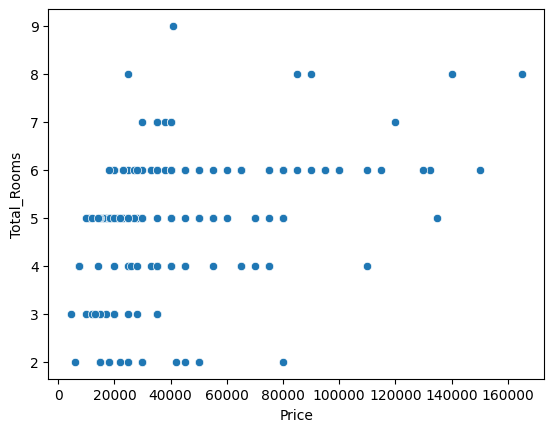

In [14]:
# What is the relationship between price and no. of rooms ?
# There is a direct relation between price and no. of rooms
sns.scatterplot(data=data , x="Price",y="Total_Rooms")

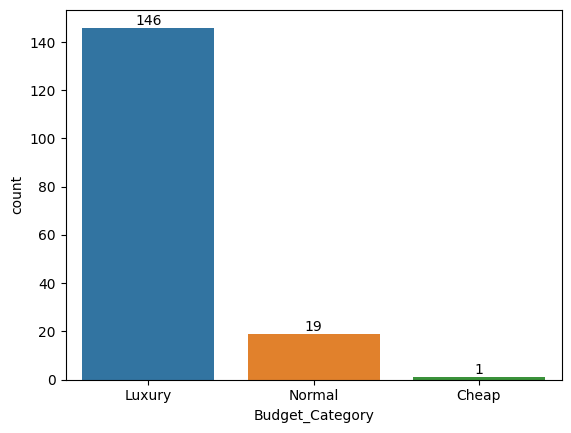

In [15]:
ax = sns.countplot(data,x="Budget_Category")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

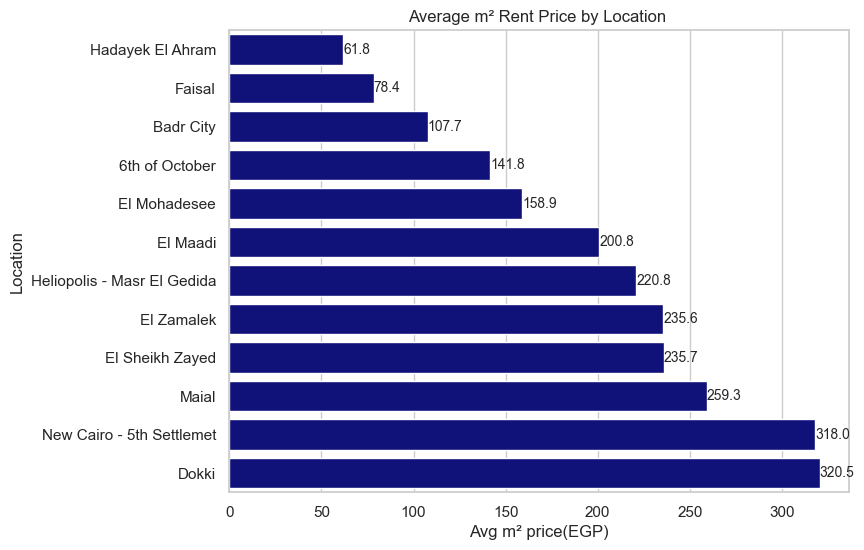

In [20]:
sorted_avg_price = data.groupby('Location')['Price_per_m²'].mean().sort_values().reset_index()

plt.figure(figsize=(8, 6)) # تكبير حجم الرسمة لتكون العناوين واضحة
ax = sns.barplot(
    data=sorted_avg_price,      # نستخدم الجدول الجديد والمرتب
    x="Price_per_m²",
    y="Location",
    color="darkblue",
    estimator="average",        # يمكن إزالتها لأننا حسبنا المتوسط بالفعل
    errorbar=None
)

ax.bar_label(ax.containers[0], fmt='%.1f', fontsize=10) # fmt='%.1f' لعرض رقم عشري واحد

# إضافة عناوين للمحاور
plt.title("Average m² Rent Price by Location ")
plt.xlabel("Avg m² price(EGP)")
plt.ylabel("Location")

plt.show()

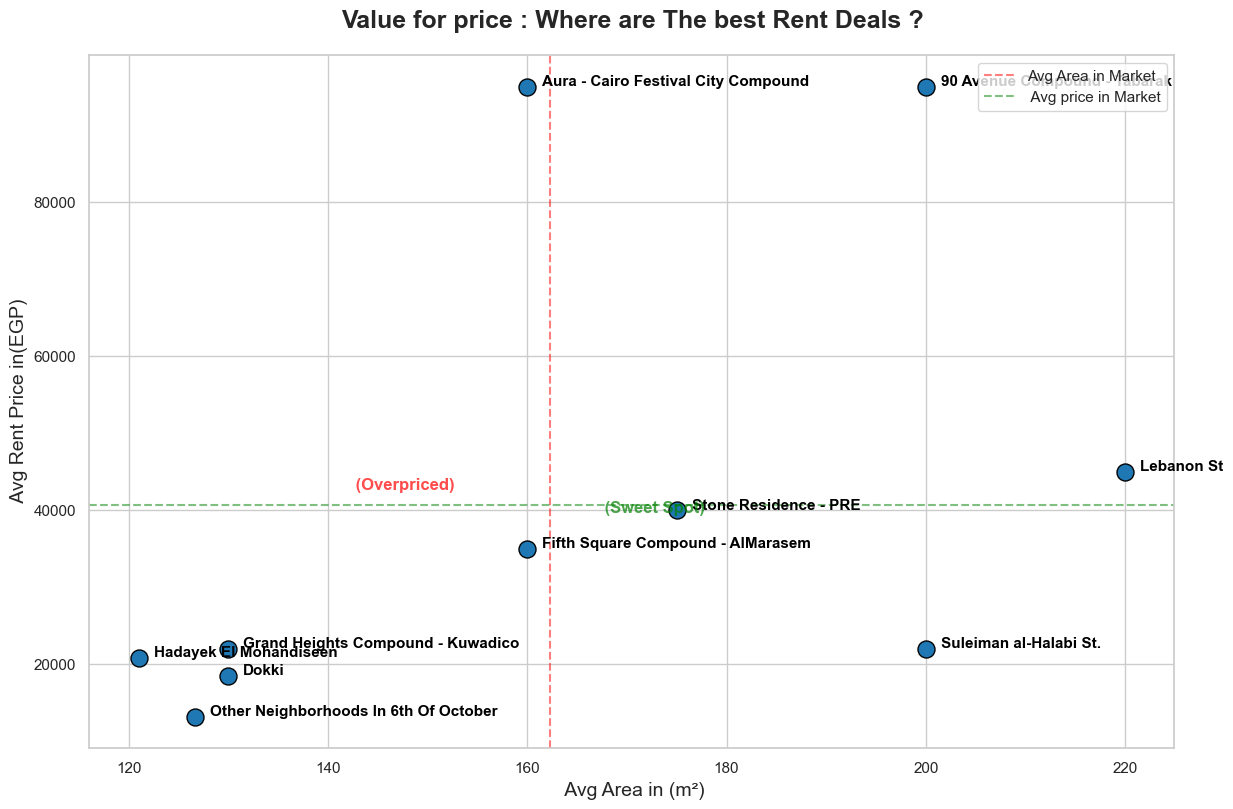

In [16]:
district_stats = data.groupby('District')[['Area', 'Price']].mean().reset_index()
district_stats = district_stats.sample(n=10, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")

ax = sns.scatterplot(
    data=district_stats, 
    x='Area', 
    y='Price', 
    s=150, 
    color='#1f77b4', 
    edgecolor='black' # تحديد أسود خفيف حول النقطة لشياكة الرسمة
)

market_avg_area = district_stats['Area'].mean()
market_avg_price = district_stats['Price'].mean()

# هنرسم خطين متقاطعين يمثلوا المتوسطات دي
plt.axvline(market_avg_area, color='red', linestyle='--', alpha=0.5, label='Avg Area in Market')
plt.axhline(market_avg_price, color='green', linestyle='--', alpha=0.5, label=' Avg price in Market')

for i in range(district_stats.shape[0]):
    plt.text(
        x=district_stats['Area'][i] + 1.5, # إزاحة بسيطة يمين عشان الكلمة متغطيش النقطة
        y=district_stats['Price'][i] + 150, # إزاحة بسيطة لفوق
        s=district_stats['District'][i],
        fontdict=dict(color='black', size=11, weight='bold')
    )


plt.text(
    x=market_avg_area + 5, 
    y=market_avg_price - 1000, 
    s=' (Sweet Spot) ', 
    color='green', fontsize=12, fontweight='bold', alpha=0.7
)

# توضيح مربع الأوفر (فوق الشمال: مساحة أقل وسعر أعلى)
plt.text(
    x=market_avg_area - 20, 
    y=market_avg_price + 2000, 
    s=' (Overpriced)', 
    color='red', fontsize=12, fontweight='bold', alpha=0.7
)


plt.title("Value for price : Where are The best Rent Deals ?", fontsize=18, fontweight='bold', pad=20)
plt.xlabel(" Avg Area in (m²)", fontsize=14)
plt.ylabel(" Avg Rent Price in(EGP)", fontsize=14)
plt.legend()

# حفظ الصورة بجودة عالية عشان تنزلها على لينكد إن واضحة
plt.savefig('Sweet_Spot_District_Analysis.png', dpi=300, bbox_inches='tight')

plt.show()

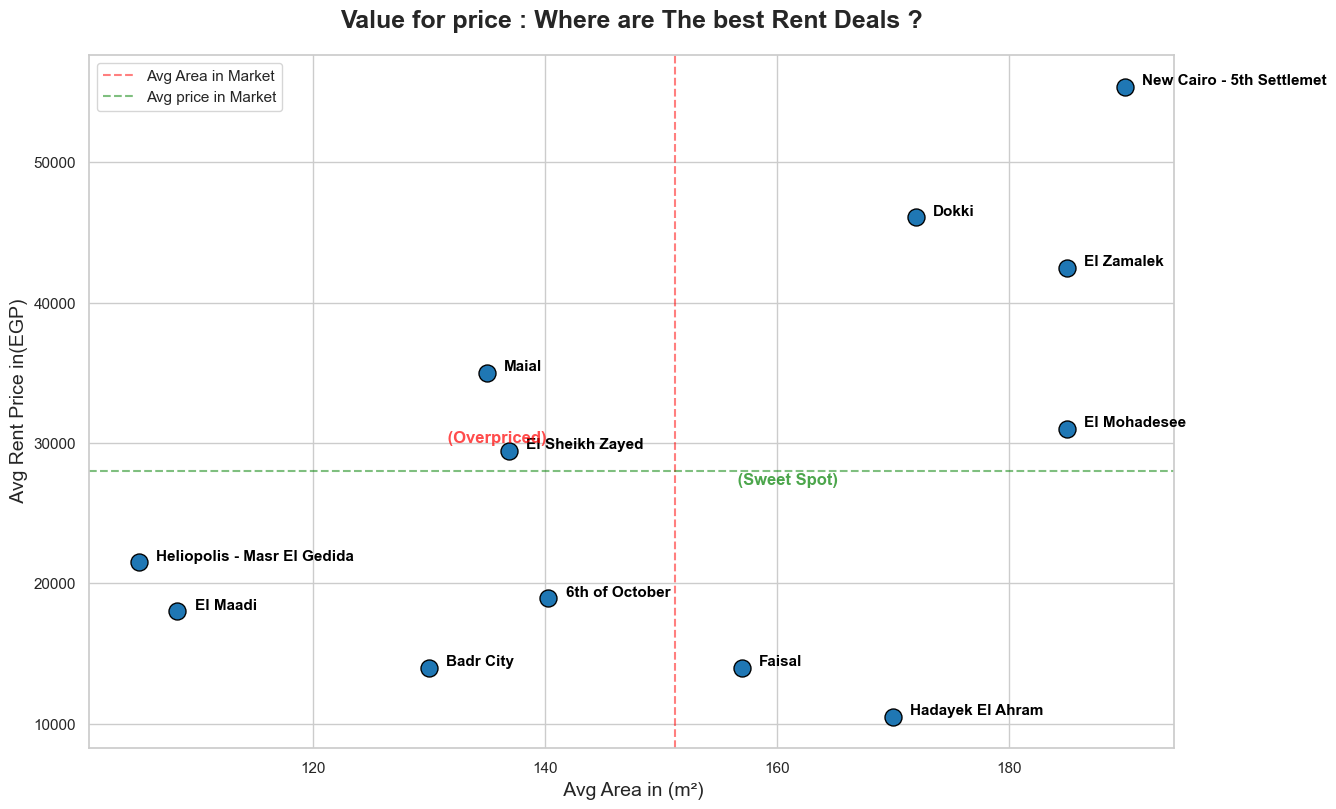

In [17]:
# تجميع البيانات بناءً على Location
location_stats = data.groupby('Location')[['Area', 'Price']].mean().reset_index()

plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")

ax = sns.scatterplot(
    data=location_stats, 
    x='Area', 
    y='Price', 
    s=150, 
    color='#1f77b4', 
    edgecolor='black' # تحديد أسود خفيف حول النقطة لشياكة الرسمة
)

market_avg_area = location_stats['Area'].mean()
market_avg_price = location_stats['Price'].mean()

# هنرسم خطين متقاطعين يمثلوا المتوسطات دي
plt.axvline(market_avg_area, color='red', linestyle='--', alpha=0.5, label='Avg Area in Market')
plt.axhline(market_avg_price, color='green', linestyle='--', alpha=0.5, label='Avg price in Market')

for i in range(location_stats.shape[0]):
    plt.text(
        x=location_stats['Area'][i] + 1.5, # إزاحة بسيطة يمين عشان الكلمة متغطيش النقطة
        y=location_stats['Price'][i] + 150, # إزاحة بسيطة لفوق
        s=location_stats['Location'][i],   # التعديل الأساسي هنا
        fontdict=dict(color='black', size=11, weight='bold')
    )

plt.text(
    x=market_avg_area + 5, 
    y=market_avg_price - 1000, 
    s=' (Sweet Spot) ', 
    color='green', fontsize=12, fontweight='bold', alpha=0.7
)

# توضيح مربع الأوفر (فوق الشمال: مساحة أقل وسعر أعلى)
plt.text(
    x=market_avg_area - 20, 
    y=market_avg_price + 2000, 
    s=' (Overpriced)', 
    color='red', fontsize=12, fontweight='bold', alpha=0.7
)

plt.title("Value for price : Where are The best Rent Deals ?", fontsize=18, fontweight='bold', pad=20)
plt.xlabel(" Avg Area in (m²)", fontsize=14)
plt.ylabel(" Avg Rent Price in(EGP)", fontsize=14)
plt.legend()

# حفظ الصورة باسم جديد عشان نحافظ على الصورة القديمة
plt.savefig('Sweet_Spot_Location_Analysis.png', dpi=300, bbox_inches='tight')

plt.show()